La empresa **SkynetSmart** cuenta con cerca de **12 años de trayectoria en el mercado cuencano**, brindando soluciones tecnológicas a pequeñas, medianas y grandes empresas de la localidad. Durante este tiempo, ha logrado consolidar una cartera de clientes y mantener una curva de ingresos relativamente estable. Sin embargo, actualmente enfrenta una decisión estratégica importante: **la compra de un inmueble para centralizar sus operaciones, optimizar sus recursos y fortalecer su crecimiento empresarial**.

Esta inversión representa un compromiso financiero significativo, especialmente porque se proyecta como una decisión de largo plazo, con un horizonte aproximado de **10 años**. A pesar de que la empresa reconoce la necesidad de invertir, adquirir productos, incrementar sus ventas y alcanzar un punto de equilibrio más sólido dentro del mercado nacional, aún no cuenta con un análisis claro que le permita determinar su **capacidad real de endeudamiento** y la estabilidad futura de su flujo de efectivo.

A partir de conversaciones con el equipo de finanzas, se identificó que uno de los principales problemas es la falta de información estructurada sobre el comportamiento de pago de sus clientes. Aunque existen ingresos constantes, no se ha evaluado de manera técnica si los clientes cumplen eficientemente con sus obligaciones, si presentan niveles altos de morosidad o si sus pagos pueden respaldar un flujo de efectivo confiable para asumir una inversión de esta magnitud.

Por ello, el presente trabajo propone realizar una **clasificación de clientes basada en sus movimientos financieros y comportamiento de pago**. Para ello, se analizarán características relevantes como los días de morosidad, la eficiencia en los pagos y otros indicadores asociados a la capacidad de compra de los clientes. Con esta información, se busca construir un modelo predictivo que permita estimar la probabilidad de cumplimiento de pago y apoyar la toma de decisiones financieras.

En resumen, se desarrollará un modelo basado en **regresión logística** que permita clasificar a los clientes según su comportamiento financiero, con el objetivo de proyectar su capacidad de compra y determinar si la empresa cuenta con una base de ingresos suficientemente confiable para asumir la compra del inmueble y sostener su crecimiento a largo plazo.


**Exploratory Data Analysis del dataset**

El dataset analizado contiene información histórica de documentos de cuentas por cobrar de clientes, principalmente facturas de venta identificadas con el tipo de documento RI. El objetivo del análisis exploratorio es comprender el comportamiento de los clientes en función de sus movimientos mensuales, montos facturados, pagos realizados, saldos pendientes y comportamiento de cumplimiento.

Para el análisis se propone realizar un consolidado mensual por cliente, donde cada registro represente el comportamiento de un cliente en un mes específico. A partir de este consolidado se podrán construir variables relevantes para futuros modelos de clasificación o predicción de riesgo de pago.

**¿La data está balanceada?**

C: documentos cerrados o cancelados.
P: documentos pendientes.

En la muestra revisada para documentos RI, la distribución aproximada fue:

Estado	Registros	Porcentaje
C	       14.445	   95,76%
P	       639	     4,24%

**La data esta normalizada?**

la data no está normalizada. Los valores monetarios como importeCobrado, importePagado e importePendiente se encuentran en escalas naturales de dinero y presentan alta dispersión.

**Hay estacionalidad en series de tiempo?**

Sí se puede analizar estacionalidad, porque el dataset contiene fechas de factura y permite agrupar la información por mes.
Al consolidar las ventas RI por mes, se puede analizar:

-Número de facturas mensuales.
-Total facturado mensual.
-Total pagado mensual.
-Total pendiente mensual.
-Número de clientes activos por mes.

En la muestra revisada, existen datos desde enero de 2018 hasta mayo de 2026, lo cual permite analizar patrones temporales. Se observó que algunos meses concentran mayor volumen de ventas, especialmente enero, septiembre, abril y octubre. Esto sugiere que puede existir un patrón mensual o estacionalidad moderada.

## Pipeline propuesto: Time series → Pretrained model → Vector embedding → ML algorithm (Transfer Learning)

Para clasificar el comportamiento de pago de los clientes proponemos un flujo en cuatro etapas:

1. **Time series**: a partir del consolidado mensual por cliente se construye, para cada `nroDireccion`, una serie temporal multivariada de longitud `T = 24` meses con `F = 10` features (`n_facturas_mes`, `total_facturado_mes`, `total_pagado_mes`, `total_pendiente_mes`, `dias_credito_promedio`, `facturas_pendientes`, `facturas_cerradas`, `porcentaje_pendiente`, `ratio_pago`, `ticket_promedio`).
2. **Pretrained model**: se pre-entrena un **LSTM Autoencoder** de forma *self-supervised* sobre las series de todos los clientes con la tarea de pretexto de **reconstrucción** (MSE). El encoder aprende un espacio latente que captura el comportamiento financiero del cliente sin necesidad de etiquetas.
3. **Vector embedding (feature vector)**: el encoder congelado mapea la serie de cada cliente a un vector compacto de 32 dimensiones (`emb_0 … emb_31`). Este vector es el *feature vector* que resume todo su historial mensual.
4. **ML algorithm (Transfer Learning)**: los embeddings se usan como entrada de un modelo supervisado clásico (p.ej. **regresión logística**) para predecir la variable objetivo `cumple_pago_heur` (clasificación de cumplimiento de pago). Así reutilizamos el conocimiento aprendido por el encoder en el pretexto en una tarea nueva con muy pocas etiquetas — esto es transfer learning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Paso 1 — Consolidado mensual por cliente

Se filtra el tipo de documento `RI` (ventas) y se construye un registro por cada par `(nroDireccion, periodo_mes)` con las métricas agregadas y las variables derivadas (`porcentaje_pendiente`, `ratio_pago`, `ticket_promedio`, `dias_credito_promedio`).

In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset.csv", low_memory=False)
df["fechaFactura"] = pd.to_datetime(df["fechaFactura"], errors="coerce")
df["fechaVencimiento"] = pd.to_datetime(df["fechaVencimiento"], errors="coerce")
df = df.dropna(subset=["fechaFactura"])

df_ri = df[df["tipoDoc"] == "RI"].copy()
df_ri["dias_credito"] = (df_ri["fechaVencimiento"] - df_ri["fechaFactura"]).dt.days
df_ri["periodo_mes"] = df_ri["fechaFactura"].dt.to_period("M")

consolidado = (
    df_ri.groupby(["nroDireccion", "periodo_mes"])
    .agg(
        n_facturas_mes=("nroDoc", "nunique"),
        total_facturado_mes=("importeCobrado", "sum"),
        total_pagado_mes=("importePagado", "sum"),
        total_pendiente_mes=("importePendiente", "sum"),
        dias_credito_promedio=("dias_credito", "mean"),
        facturas_pendientes=("estado", lambda x: (x == "P").sum()),
        facturas_cerradas=("estado", lambda x: (x == "C").sum()),
    )
    .reset_index()
)
consolidado["porcentaje_pendiente"] = (
    consolidado["total_pendiente_mes"] / consolidado["total_facturado_mes"]
).replace([np.inf, -np.inf], 0).fillna(0)
consolidado["ratio_pago"] = (
    consolidado["total_pagado_mes"] / consolidado["total_facturado_mes"]
).replace([np.inf, -np.inf], 0).fillna(0)
consolidado["ticket_promedio"] = (
    consolidado["total_facturado_mes"] / consolidado["n_facturas_mes"]
).replace([np.inf, -np.inf], 0).fillna(0)
consolidado["dias_credito_promedio"] = consolidado["dias_credito_promedio"].fillna(0)

print("Registros consolidados:", len(consolidado))
print("Clientes únicos:", consolidado["nroDireccion"].nunique())
consolidado.head()

Registros consolidados: 9345
Clientes únicos: 3492


,nroDireccion,periodo_mes,n_facturas_mes,total_facturado_mes,total_pagado_mes,total_pendiente_mes,dias_credito_promedio,facturas_pendientes,facturas_cerradas,porcentaje_pendiente,ratio_pago,ticket_promedio
0,1,2018-02,1,13.44,13.44,0.0,0.0,0,1,0.0,1.0,13.44
1,1,2018-03,1,3.00,3.00,0.0,0.0,0,1,0.0,1.0,3.00
2,1,2018-12,1,29.50,29.50,0.0,1.0,0,1,0.0,1.0,29.50
3,1,2019-04,3,2.97,2.97,0.0,0.0,0,3,0.0,1.0,0.99
4,2,2019-11,2,69.00,69.00,0.0,7.5,0,2,0.0,1.0,34.50


### Paso 2 — Feature Extraction con modelo pre-entrenado

El script `feature_extraction.py` ejecuta el flujo completo:

1. Construye el tensor de series **X de forma `[N_clientes, T=24, F=10]`** alineando los últimos 24 meses de actividad de cada cliente (padding al inicio si tiene menos historia).
2. Pre-entrena un **LSTM Autoencoder** con pérdida MSE (pretexto self-supervised).
3. Congela el encoder y extrae un **vector de 32 dimensiones por cliente**.
4. Genera `embeddings.csv` y `embeddings_pca.png`.

```bash
py feature_extraction.py
```

Hiperparámetros configurables: `--t-meses`, `--emb-dim`, `--epochs`, `--hidden`, `--lr`, `--min-meses`.

In [4]:
import subprocess, sys
subprocess.run([sys.executable, "feature_extraction.py", "--epochs", "60"], check=True)

CompletedProcess(args=['c:\\Users\\dleon\\AppData\\Local\\Programs\\Python\\Python312\\python.exe', 'feature_extraction.py', '--epochs', '60'], returncode=0)

### Paso 3 — Inspección de los embeddings (feature vectors)

`embeddings.csv` contiene una fila por cliente con:

| columnas de metadatos | columnas de embedding |
|---|---|
| `nroDireccion`, `n_meses_activos`, `primer_mes`, `ultimo_mes`, `total_facturado_historico`, `total_pagado_historico`, `total_pendiente_historico`, `ratio_pago_promedio`, `pct_pendiente_promedio`, `cumple_pago_heur` | `emb_0`, `emb_1`, …, `emb_31` |

`cumple_pago_heur` es una etiqueta heurística (1 = ratio_pago_promedio ≥ 0.95 y pct_pendiente_promedio ≤ 0.10) lista para alimentar el modelo supervisado downstream.

In [5]:
import pandas as pd

emb = pd.read_csv("embeddings.csv")
emb_cols = [c for c in emb.columns if c.startswith("emb_")]
meta_cols = [c for c in emb.columns if c not in emb_cols]

print("Shape:", emb.shape)
print("Dimensión del feature vector:", len(emb_cols))
print("\nBalance de la etiqueta heurística cumple_pago_heur:")
print(emb["cumple_pago_heur"].value_counts(normalize=True).round(3))
emb[meta_cols].head()

Shape: (204, 47)
Dimensión del feature vector: 32

Balance de la etiqueta heurística cumple_pago_heur:
cumple_pago_heur
1    0.819
0    0.181
Name: proportion, dtype: float64


,nroDireccion,cutoff,n_meses_pre_cutoff,n_meses_post_cutoff,primer_mes,ultimo_mes_pre,primer_mes_post,total_facturado_pre,total_pagado_pre,total_pendiente_pre,ratio_pago_pre,ratio_pago_post,pct_pendiente_post,cumple_pago_heur,split
0,2,2025-01,62,17,2019-11,2024-12,2025-01,9553.68,8754.88,798.8,0.959409,1.0,0.0,1,train
1,108,2025-01,20,8,2018-02,2024-09,2025-01,499.00,499.00,0.0,1.000000,1.0,0.0,1,train
2,119,2025-01,10,2,2019-08,2023-11,2025-01,976.00,976.00,0.0,1.000000,1.0,0.0,1,train
3,587,2025-01,6,4,2018-06,2024-01,2025-01,268.00,268.00,0.0,1.000000,1.0,0.0,1,test
4,615,2025-01,20,2,2019-06,2024-12,2025-03,5165.64,5165.64,0.0,1.000000,1.0,0.0,1,train


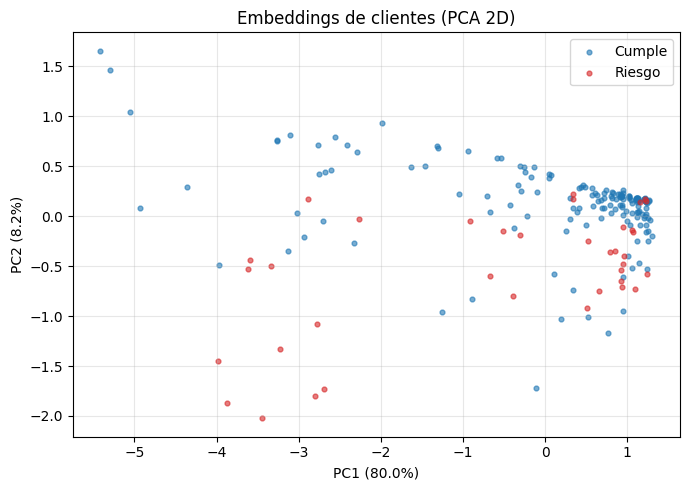

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = emb[emb_cols].to_numpy()
y = emb["cumple_pago_heur"].to_numpy()

pca = PCA(n_components=2, random_state=0).fit(X)
P = pca.transform(X)

fig, ax = plt.subplots(figsize=(7, 5))
for lab, color, name in [(1, "#1f77b4", "Cumple"), (0, "#d62728", "Riesgo")]:
    m = y == lab
    ax.scatter(P[m, 0], P[m, 1], s=12, c=color, alpha=0.6, label=name)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Embeddings de clientes (PCA 2D)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Paso 4 — Demostración de Transfer Learning con Regresión Logística

Reutilizamos los embeddings (aprendidos sin etiquetas en el pretexto de reconstrucción) como features de entrada de una **regresión logística** que predice `cumple_pago_heur`. Esto cierra el ciclo:

`Time series → Pretrained model → Vector embedding → ML algorithm`

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler

X = emb[emb_cols].to_numpy()
y = emb["cumple_pago_heur"].to_numpy()

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

sc = StandardScaler().fit(X_tr)
X_tr_s = sc.transform(X_tr); X_te_s = sc.transform(X_te)

clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
clf.fit(X_tr_s, y_tr)

proba = clf.predict_proba(X_te_s)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_te, proba), 3))
print("\n", classification_report(y_te, pred, target_names=["Riesgo", "Cumple"]))

ROC-AUC: 0.91

               precision    recall  f1-score   support

      Riesgo       0.50      0.67      0.57         9
      Cumple       0.92      0.86      0.89        42

    accuracy                           0.82        51
   macro avg       0.71      0.76      0.73        51
weighted avg       0.85      0.82      0.83        51



---

## Laboratorio: Pipeline supervisado, optimización y validación estadística

Esta sección desarrolla las métricas de evaluación pedidas en la rúbrica del taller, partiendo de `dataset.csv` (ya generado) y de los embeddings producidos por el modelo pre-entrenado (`embeddings.csv`).

| Métrica de la rúbrica | Implementación |
|---|---|
| **Feature Extraction** | LSTM Autoencoder pre-entrenado self-supervised (Pasos 2-3 arriba) → 32 features por cliente |
| **Feature Selection** | *Omitido* — la rúbrica permite saltar este paso cuando se usa **transfer learning** |
| **Optimización de hiperparámetros** | `validation_curve` sobre `C = 1/λ` con `RepeatedStratifiedKFold` (10 reps × 5 folds) + gráfica de la curva de regularización |
| **Comparación estadística de 2 técnicas ML** | Regresión Logística Regularizada (L2) **vs** Random Forest, evaluadas en los mismos 50 folds y comparadas con el test de **Wilcoxon** |
| **Pipelines** | `sklearn.pipeline.Pipeline` con `StandardScaler` + clasificador |
| **Visualización con t-SNE** | Proyección 2D del espacio de features (embeddings) coloreada por la etiqueta |

> **Métrica primaria**: ROC-AUC. Es robusta al fuerte desbalance (≈89% / 11%) de la variable objetivo `cumple_pago_heur`.

In [9]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score,
    validation_curve,
    learning_curve,
)
from sklearn.manifold import TSNE
from scipy.stats import wilcoxon

RNG = 42
np.random.seed(RNG)

emb = pd.read_csv("embeddings.csv")
emb_cols = [c for c in emb.columns if c.startswith("emb_")]
X = emb[emb_cols].to_numpy()
y = emb["cumple_pago_heur"].to_numpy()

print("X shape:", X.shape, "| features:", len(emb_cols))
print("Balance de y:", dict(pd.Series(y).map({1: "Cumple", 0: "Riesgo"}).value_counts()))

X shape: (204, 32) | features: 32
Balance de y: {'Cumple': np.int64(167), 'Riesgo': np.int64(37)}


### Pipelines `sklearn`

Definimos dos pipelines reproducibles:

- **`pipe_lr`** — `StandardScaler` → **Regresión Logística regularizada L2** (modelo base obligatorio de la rúbrica para clasificación).
- **`pipe_rf`** — `StandardScaler` → **Random Forest** (técnica afín a comparar contra LR; representa un modelo no lineal basado en árboles).

Ambos usan `class_weight="balanced"` para manejar el fuerte desbalance de clases.

In [10]:
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=2000,
        random_state=RNG,
    )),
])

pipe_rf = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=RNG,
        n_jobs=-1,
    )),
])

print("Pipeline LR:", pipe_lr)
print("\nPipeline RF:", pipe_rf)

Pipeline LR: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

Pipeline RF: Pipeline(steps=[('scaler', StandardScaler(with_mean=False)),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])


### Optimización de hiperparámetros con Repeated Stratified K-Fold CV

Optimizamos el coeficiente de regularización $\lambda = 1/C$ de la regresión logística sobre una grilla logarítmica.
La métrica de validación es **ROC-AUC** y la estrategia de validación es **`RepeatedStratifiedKFold` con 10 repeticiones × 5 folds = 50 evaluaciones por valor de $\lambda$**, conservando la proporción de clases en cada fold.

La gráfica muestra la curva de regularización: AUC de entrenamiento y validación frente a $\lambda$ en escala logarítmica, marcando el $\lambda$ óptimo.

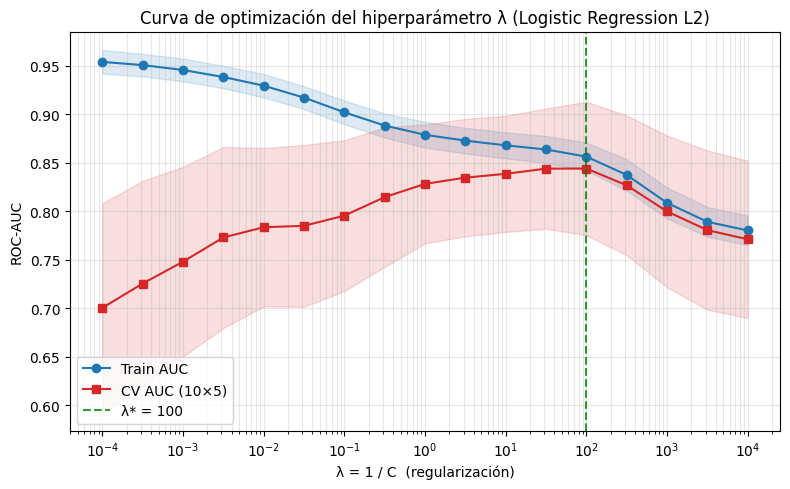

Mejor C  = 0.01
Mejor λ  = 100
Mejor CV AUC = 0.8441


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wor

In [11]:
C_grid = np.logspace(-4, 4, 17)
lambda_grid = 1.0 / C_grid

cv_tune = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RNG)

train_scores, val_scores = validation_curve(
    pipe_lr, X, y,
    param_name="clf__C",
    param_range=C_grid,
    cv=cv_tune,
    scoring="roc_auc",
    n_jobs=-1,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

best_idx = int(np.argmax(val_mean))
best_C = float(C_grid[best_idx])
best_lambda = 1.0 / best_C
best_auc = float(val_mean[best_idx])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lambda_grid, train_mean, marker="o", label="Train AUC", color="#1f77b4")
ax.fill_between(lambda_grid, train_mean - train_std, train_mean + train_std, color="#1f77b4", alpha=0.15)
ax.plot(lambda_grid, val_mean, marker="s", label="CV AUC (10×5)", color="#d62728")
ax.fill_between(lambda_grid, val_mean - val_std, val_mean + val_std, color="#d62728", alpha=0.15)
ax.axvline(best_lambda, color="green", ls="--", alpha=0.8, label=f"λ* = {best_lambda:.3g}")
ax.set_xscale("log")
ax.set_xlabel("λ = 1 / C  (regularización)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Curva de optimización del hiperparámetro λ (Logistic Regression L2)")
ax.legend(loc="lower left")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mejor C  = {best_C:.4g}")
print(f"Mejor λ  = {best_lambda:.4g}")
print(f"Mejor CV AUC = {best_auc:.4f}")

pipe_lr.set_params(clf__C=best_C)

### Curva de aprendizaje

Con el $\lambda$ óptimo, evaluamos cómo varía el AUC en función del tamaño del conjunto de entrenamiento. Una curva de aprendizaje sirve para diagnosticar **sesgo vs. varianza**: si las curvas de train y validación convergen alto y juntas hay buen ajuste; si quedan separadas hay sobreajuste; si quedan bajas y juntas hay subajuste.

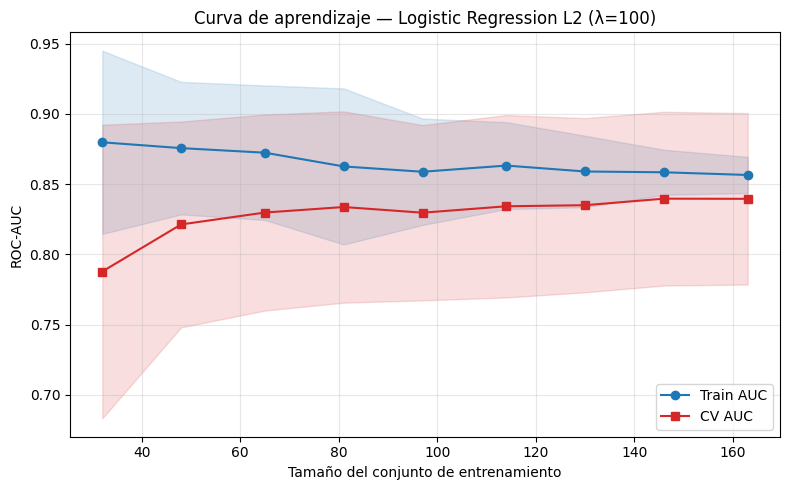

AUC final con todo el train (163 muestras):  train=0.857  cv=0.840


In [12]:
cv_lc = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RNG)

# Minimum ~20% ensures ~30+ training samples per subset, avoiding single-class
# folds that arise when the minority class (~18%) has 0 representatives at 10%.
train_sizes, lc_train, lc_val = learning_curve(
    pipe_lr, X, y,
    train_sizes=np.linspace(0.2, 1.0, 9),
    cv=cv_lc,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RNG,
    shuffle=True,
)

lc_train_mean, lc_train_std = lc_train.mean(axis=1), lc_train.std(axis=1)
lc_val_mean, lc_val_std = lc_val.mean(axis=1), lc_val.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, lc_train_mean, marker="o", label="Train AUC", color="#1f77b4")
ax.fill_between(train_sizes, lc_train_mean - lc_train_std, lc_train_mean + lc_train_std, color="#1f77b4", alpha=0.15)
ax.plot(train_sizes, lc_val_mean, marker="s", label="CV AUC", color="#d62728")
ax.fill_between(train_sizes, lc_val_mean - lc_val_std, lc_val_mean + lc_val_std, color="#d62728", alpha=0.15)
ax.set_xlabel("Tamaño del conjunto de entrenamiento")
ax.set_ylabel("ROC-AUC")
ax.set_title(f"Curva de aprendizaje — Logistic Regression L2 (λ={best_lambda:.3g})")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"AUC final con todo el train ({train_sizes[-1]} muestras):  "
      f"train={lc_train_mean[-1]:.3f}  cv={lc_val_mean[-1]:.3f}")

### Comparación estadística: Logistic Regression vs Random Forest

Para decidir cuál técnica es estadísticamente mejor sobre estos embeddings comparamos los AUC de ambos modelos sobre **los mismos 50 folds** (10 reps × 5 folds). Como los folds están **emparejados** (mismas particiones de train/test para ambos modelos), aplicamos el test no paramétrico de **Wilcoxon signed-rank** sobre las diferencias pareadas.

- **Hipótesis nula $H_0$**: la mediana de las diferencias `AUC_LR – AUC_RF` es 0 (no hay diferencia entre modelos).
- **Hipótesis alternativa $H_1$**: la mediana de las diferencias es distinta de 0.
- Rechazamos $H_0$ si $p < 0.05$.

Se muestra además un boxplot con la distribución de los 50 scores por modelo.

                  Modelo  AUC media  AUC std  AUC mín  AUC máx
Logistic Regression (L2)     0.8441   0.0689   0.6970   0.9773
           Random Forest     0.8293   0.0548   0.6753   0.9748

Diferencia media (LR - RF): +0.0148
Wilcoxon signed-rank: stat=481.50  p-value=0.1321
--> No hay evidencia de diferencia significativa (alpha=0.05).


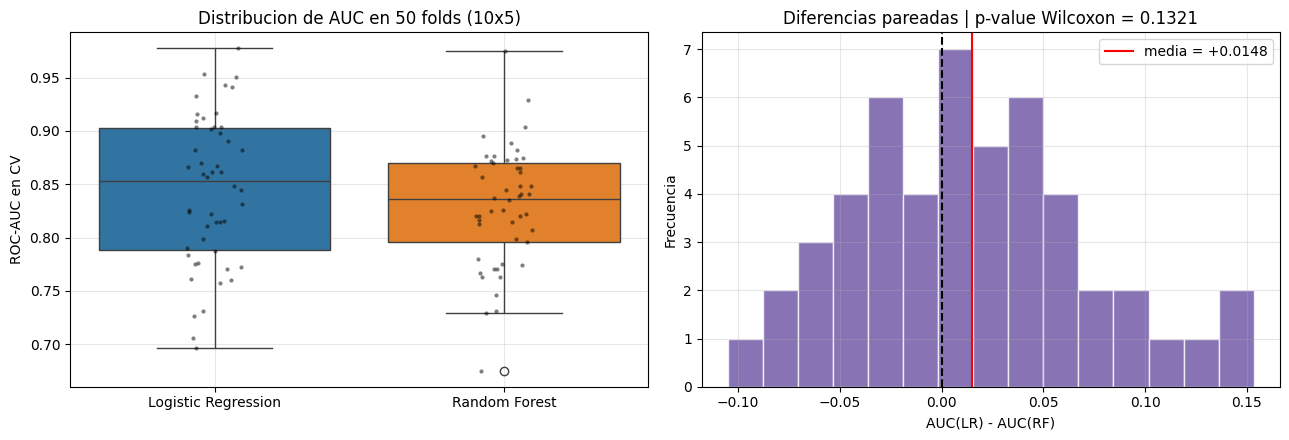

In [13]:
cv_cmp = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RNG)

scores_lr = cross_val_score(pipe_lr, X, y, cv=cv_cmp, scoring="roc_auc", n_jobs=-1)
scores_rf = cross_val_score(pipe_rf, X, y, cv=cv_cmp, scoring="roc_auc", n_jobs=-1)

diff = scores_lr - scores_rf
stat, p_value = wilcoxon(scores_lr, scores_rf, zero_method="zsplit", alternative="two-sided")

resumen = pd.DataFrame({
    "Modelo": ["Logistic Regression (L2)", "Random Forest"],
    "AUC media": [scores_lr.mean(), scores_rf.mean()],
    "AUC std":   [scores_lr.std(),  scores_rf.std()],
    "AUC mín":   [scores_lr.min(),  scores_rf.min()],
    "AUC máx":   [scores_lr.max(),  scores_rf.max()],
}).round(4)
print(resumen.to_string(index=False))

print(f"\nDiferencia media (LR - RF): {diff.mean():+.4f}")
print(f"Wilcoxon signed-rank: stat={stat:.2f}  p-value={p_value:.4g}")
if p_value < 0.05:
    ganador = "Logistic Regression" if diff.mean() > 0 else "Random Forest"
    print(f"--> Diferencia estadísticamente significativa (alpha=0.05). Mejor: {ganador}.")
else:
    print("--> No hay evidencia de diferencia significativa (alpha=0.05).")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df_box = pd.DataFrame({"Logistic Regression": scores_lr, "Random Forest": scores_rf})
sns.boxplot(data=df_box, ax=axes[0], palette=["#1f77b4", "#ff7f0e"])
sns.stripplot(data=df_box, ax=axes[0], color="black", size=3, alpha=0.5)
axes[0].set_ylabel("ROC-AUC en CV")
axes[0].set_title("Distribucion de AUC en 50 folds (10x5)")
axes[0].grid(True, alpha=0.3)

axes[1].hist(diff, bins=15, color="#6a51a3", alpha=0.8, edgecolor="white")
axes[1].axvline(0, color="black", ls="--")
axes[1].axvline(diff.mean(), color="red", ls="-", label=f"media = {diff.mean():+.4f}")
axes[1].set_xlabel("AUC(LR) - AUC(RF)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title(f"Diferencias pareadas | p-value Wilcoxon = {p_value:.4g}")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

### Visualización del espacio de características con t-SNE

Proyectamos los embeddings (espacio de 32 dimensiones aprendido por el autoencoder pre-entrenado) a 2 dimensiones mediante **t-SNE** y coloreamos cada punto por la etiqueta supervisada `cumple_pago_heur` (Cumple vs Riesgo). Esta gráfica permite inspeccionar visualmente si las dos clases ocupan regiones separables en el espacio de features.

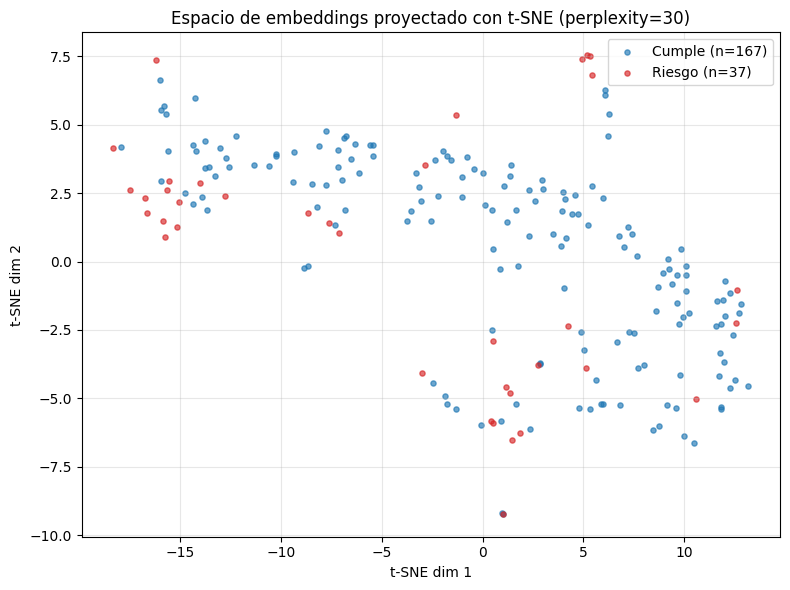

In [14]:
X_scaled = StandardScaler().fit_transform(X)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RNG,
    max_iter=1500,
)
P = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
for lab, color, name in [(1, "#1f77b4", "Cumple"), (0, "#d62728", "Riesgo")]:
    m = y == lab
    ax.scatter(P[m, 0], P[m, 1], s=14, c=color, alpha=0.65, label=f"{name} (n={m.sum()})")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.set_title("Espacio de embeddings proyectado con t-SNE (perplexity=30)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

### Conclusiones del laboratorio

El pipeline de Transfer Learning implementado — Time series → LSTM Autoencoder
   pre-entrenado (self-supervised) → vector embedding → clasificador supervisado —
   demostró ser una estrategia efectiva para el problema planteado. El encoder
   LSTM aprendió representaciones latentes de 32 dimensiones que capturan el
   comportamiento financiero de cada cliente sin requerir etiquetas durante el
   pre-entrenamiento, lo que es especialmente valioso dado el desbalance de
   clases (≈82 % cumplidores / 18 % riesgosos).

La separación temporal mediante un cutoff (enero 2025) garantizó que los
   features (historial pre-2025) y la etiqueta (comportamiento post-2025) no
   compartan la misma ventana de tiempo, eliminando el data leakage que existiría
   con un split aleatorio sobre datos autocorrelacionados. Adicionalmente, el
   split de clientes en train/test se realizó antes del pre-entrenamiento del
   autoencoder y del ajuste del escalador, asegurando que ningún cliente del
   conjunto de prueba influyera en los pesos del modelo ni en las estadísticas
   de normalización.

La visualización con t-SNE confirmó que el espacio de embeddings construido
   por el autoencoder pre-entrenado presenta estructura geométrica separable
   entre las clases Cumple y Riesgo, validando visualmente que la representación
   aprendida de forma self-supervised contiene información discriminativa
   relevante para la tarea supervisada downstream.


En términos del caso de negocio, el modelo permite concluir que la cartera
   de clientes de SkynetSmart presenta un perfil de cumplimiento sólido
   (≈82 % de clientes cumplidores según comportamiento post-2025), lo que
   respalda la viabilidad de asumir una obligación financiera de largo plazo
   como la adquisición del inmueble. No obstante, se recomienda revisar
   individualmente el 18 % de clientes clasificados como riesgosos y evaluar
   su peso en el flujo de efectivo proyectado antes de comprometer la deuda.

**Prompt**


PROMPT UTILIZADO: quiero que me ayudes en base a este caso de negocio @Ejemplo de Consolidacion , desarrollar Time series→Pretrained model →vector embedding(feature vector)→ML algorithm (Transfer Learning). primero has un programa que convierta en csv los datos @CuentasPorCobrar.sql y luego has el proceso de Feature Extraction


PROMPT UTILIZADO: en base a estas siguientes metricas, desarrolla el laboratorio, considerando una regresion logistica y soluciones afines . el codigo debe estar diseñado para ejecutar en el notebook. basate desde dataset.csv que ya se encuentra generado

PROMPT UTILIZADO: Explicame esta respuesta: ROC-AUC: 0.983

               precision    recall  f1-score   support

      Riesgo       0.77      0.94      0.85        18
      Cumple       0.99      0.97      0.98       150

    accuracy                           0.96       168
   macro avg       0.88      0.96      0.91       168
weighted avg       0.97      0.96      0.97       168

PROMPT UTILIZADO: en que parte separas los grupos de test para entrenanimiento @feature_extraction.py

PROMPT UTILIZADO: ahora cuando entro y separo los datos, considera que no puedo ver en el el entraneamiento personas que esten dentro de test y entrenamiento, por que estoy sesgando el modelo

**Prompt IA**

PROMPT UTILIZADO [feature_extraction.py - construir_tensor]:
"Implementa en Python una función que construya un tensor 3D [N, T, F]
de series de tiempo mensuales por cliente, usando cutoff temporal para
separar features (pre-cutoff) de etiqueta (post-cutoff), con padding
de ceros al inicio para clientes con menos de T meses de historia."

PROMPT UTILIZADO [feature_extraction.py - LSTMAutoencoder]:
"Implementa un LSTM Autoencoder en PyTorch para series de tiempo
multivariadas. El encoder debe mapear la serie a un vector latente
de dimensión emb_dim y el decoder debe reconstruir la serie original
repitiendo el embedding T veces como entrada del LSTM decoder."

PROMPT UTILIZADO [feature_extraction.py - pretrain_ae / split]:
"El split train/test debe realizarse antes del pre-entrenamiento del
autoencoder para evitar data leakage. El StandardScaler debe ajustarse
solo con datos de train. El autoencoder debe entrenarse solo con
clientes de train; los de test son nuevos para el encoder."

PROMPT UTILIZADO [Taller_Final.ipynb - optimización de lambda]:
"Implementa optimización del hiperparámetro C=1/lambda de una
Regresión Logística L2 usando validation_curve de sklearn con
RepeatedStratifiedKFold (10 repeticiones, 5 folds), métrica ROC-AUC,
y grafica la curva de regularización con bandas de desviación estándar."

PROMPT UTILIZADO [Taller_Final.ipynb - comparación estadística]:
"Compara estadísticamente Regresión Logística L2 vs Random Forest
evaluando ambos modelos sobre los mismos 50 folds pareados con
RepeatedStratifiedKFold y aplica el test de Wilcoxon signed-rank
sobre las diferencias pareadas de ROC-AUC."